Exploration(search for best data distribution, be carefull about time spend to find the best distribution) and Exploitation(apply for better performance)
The goal is to find the best distribution in minmum time

Upper Confidence Band (UCB), the one closest to AI and building robots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_excel(r'E:\AI Projects\ML Course\ReinforcementLearning\Ads.xlsx')

In [3]:
import math

N = 60 # number of rounds in which ads started to show to the users
d = 10 # number of ads
ads_selected = []
numbers_of_selections = [0] * d
sums_of_rewards = [0] * d
total_reward = 0

for n in range(0, N):
    ad = 0
    max_upper_bound = 0
    for i in range(0, d):
        if (numbers_of_selections[i] > 0):    # UCB formula defines here
            average_reward = sums_of_rewards[i] / numbers_of_selections[i]
            delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections[i])
            upper_bound = average_reward + delta_i
        else:
            upper_bound = 1e400   # instead of infinity we asign a super high value, it's a trick in python
        if (upper_bound > max_upper_bound):
            max_upper_bound = upper_bound 
            ad = i
        ads_selected.append(ad)
        numbers_of_selections[ad] = numbers_of_selections[ad] + 1
        reward = dataset.values[n, ad]
        sums_of_rewards[ad] = sums_of_rewards[ad] + reward
        total_reward = total_reward + reward


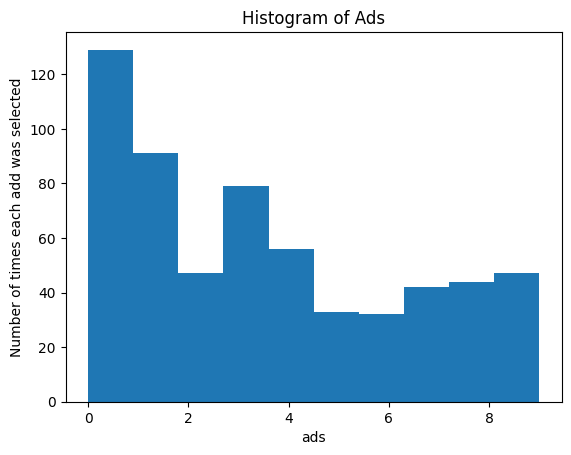

In [4]:
plt.hist(ads_selected)
plt.title('Histogram of Ads')
plt.xlabel('ads')
plt.ylabel('Number of times each add was selected')
plt.show()